In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

In [2]:
data = pd.read_csv('D:\Github\Catatan_Notebook\Analisis_Meteorologi\open_meteo_jerukagung\cuaca_jerukagung.csv')

In [3]:
data.describe()

,temperature,humidity,dewpoint,rain_mm,wind_speed,wind_direction,pressure,sunshine_duration,cloud_cover,weather_code
count,230280.000000,230280.000000,230280.000000,230280.000000,230280.000000,230280.000000,230280.000000,230280.000000,230280.000000,230280.000000
mean,25.610519,85.301515,22.829693,0.269314,8.198671,164.245878,1008.225939,1430.252141,77.680771,21.633316
std,2.176430,9.843646,1.465028,0.857751,5.122294,97.734822,2.051803,1719.237207,28.664511,24.880337
min,16.745000,41.087536,13.145000,0.000000,0.000000,0.895156,998.936700,0.000000,0.000000,0.000000
25%,23.995000,78.602217,22.095000,0.000000,4.349896,100.784256,1006.827200,0.000000,59.000000,2.000000
50%,25.445000,87.412370,23.045000,0.000000,6.830519,133.667850,1008.291750,0.000000,94.000000,3.000000
75%,27.295000,93.596437,23.800000,0.200000,10.948973,249.443880,1009.681700,3600.000000,100.000000,51.000000
max,33.094997,100.000000,27.445000,61.000000,35.295610,360.000000,1015.904700,3600.000000,100.000000,65.000000


<Axes: >

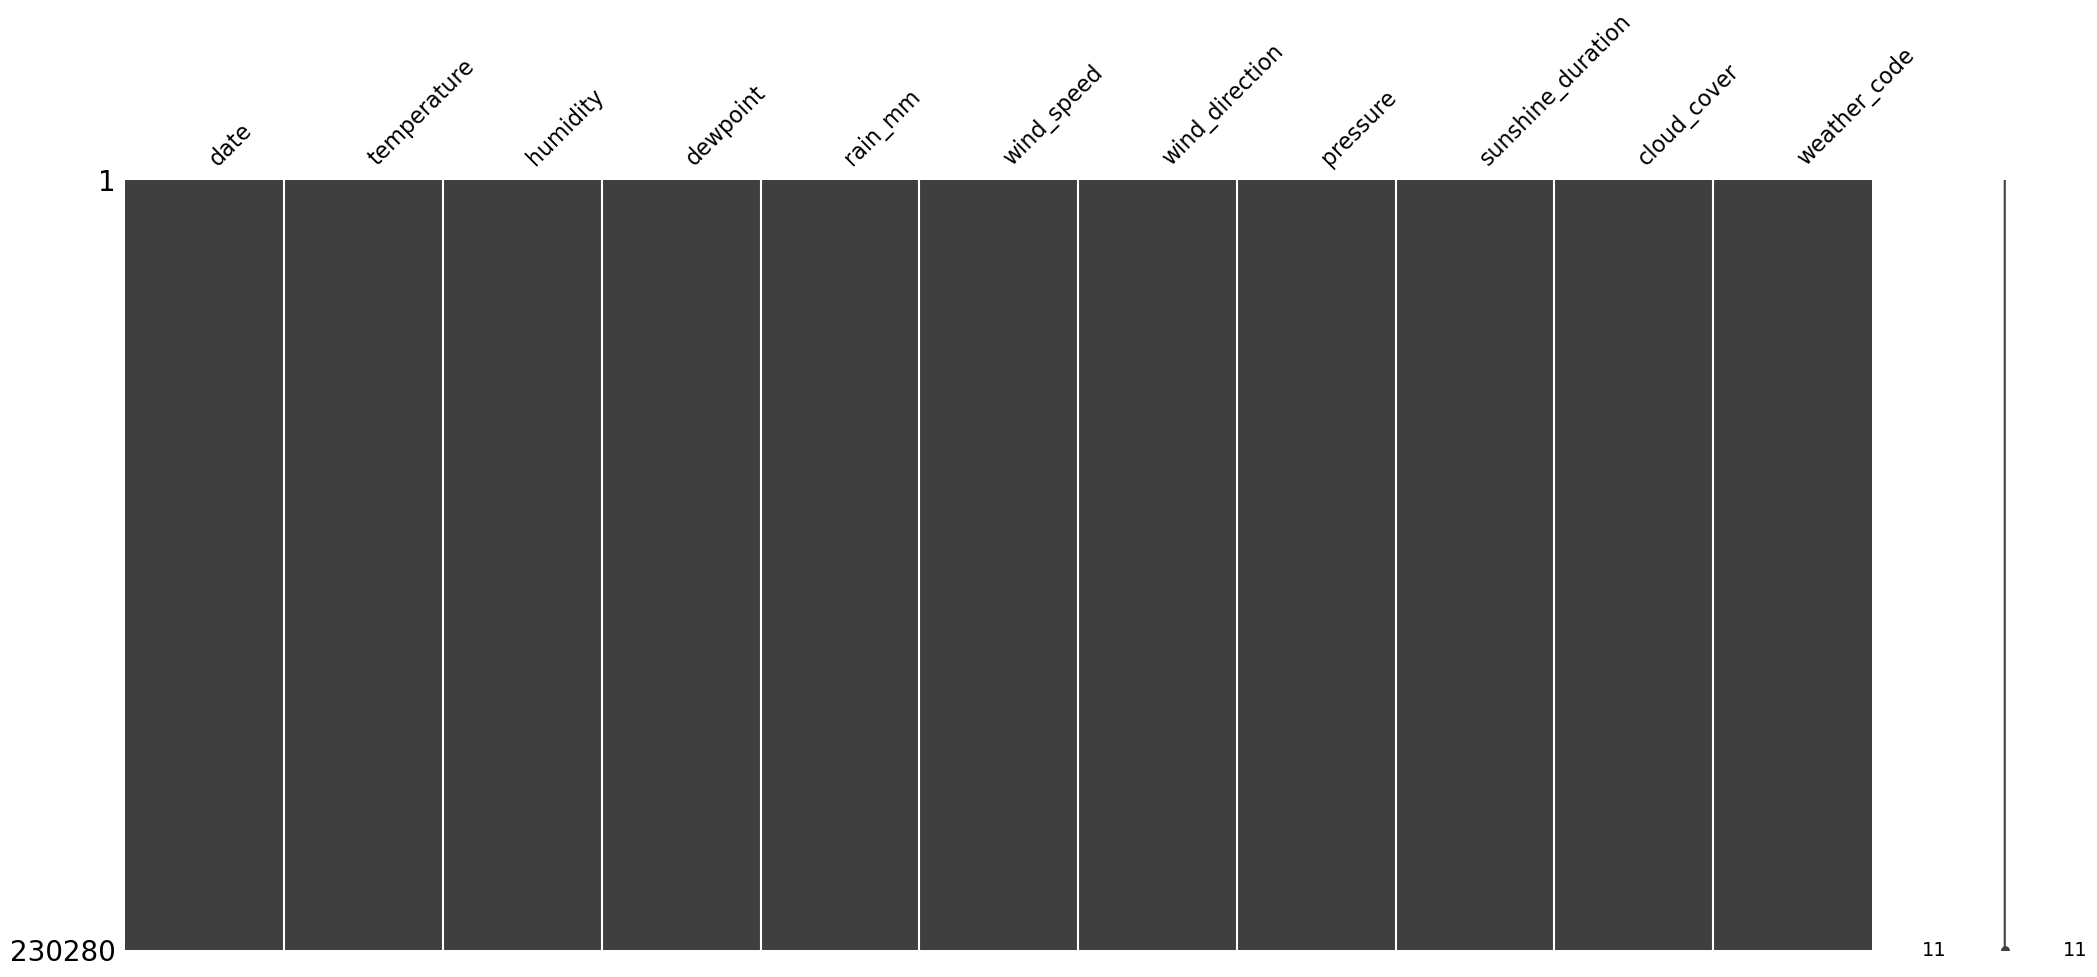

In [4]:
msno.matrix(data)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 230280 entries, 0 to 230279
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   date               230280 non-null  object 
 1   temperature        230280 non-null  float64
 2   humidity           230280 non-null  float64
 3   dewpoint           230280 non-null  float64
 4   rain_mm            230280 non-null  float64
 5   wind_speed         230280 non-null  float64
 6   wind_direction     230280 non-null  float64
 7   pressure           230280 non-null  float64
 8   sunshine_duration  230280 non-null  float64
 9   cloud_cover        230280 non-null  float64
 10  weather_code       230280 non-null  float64
dtypes: float64(10), object(1)
memory usage: 19.3+ MB


In [6]:
data

,date,temperature,humidity,dewpoint,rain_mm,wind_speed,wind_direction,pressure,sunshine_duration,cloud_cover,weather_code
0,2000-01-01 00:00:00+07:00,24.945,88.407080,22.895,0.0,3.415260,71.564964,1005.70820,0.0,100.0,3.0
1,2000-01-01 01:00:00+07:00,23.945,94.717830,23.045,0.0,2.811690,219.805530,1005.50134,0.0,98.0,3.0
2,2000-01-01 02:00:00+07:00,24.545,91.647650,23.095,0.0,2.902413,150.255200,1005.00684,0.0,98.0,3.0
3,2000-01-01 03:00:00+07:00,23.495,93.841540,22.445,0.5,2.036468,44.999897,1004.59980,0.0,98.0,53.0
4,2000-01-01 04:00:00+07:00,22.895,95.838010,22.195,0.0,2.811690,39.805527,1004.39580,0.0,100.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...
230275,2026-04-08 19:00:00+07:00,24.850,99.108170,24.700,2.8,10.853866,354.289500,1009.49920,0.0,100.0,63.0
230276,2026-04-08 20:00:00+07:00,24.850,98.223274,24.550,4.7,8.149847,353.659900,1010.29740,0.0,100.0,63.0
230277,2026-04-08 21:00:00+07:00,24.650,97.633760,24.250,3.7,5.623380,50.194473,1010.19610,0.0,100.0,63.0
230278,2026-04-08 22:00:00+07:00,24.700,97.634600,24.300,0.8,0.648999,56.309914,1011.29407,0.0,100.0,53.0


In [7]:
data['date'] = pd.to_datetime(data['date'])

In [8]:
data.isnull().sum()

date                 0
temperature          0
humidity             0
dewpoint             0
rain_mm              0
wind_speed           0
wind_direction       0
pressure             0
sunshine_duration    0
cloud_cover          0
weather_code         0
dtype: int64

# Penyaringan Data

In [9]:
# Pilih kolom yang diinginkan
selected_columns = [
    'temperature',  
    'humidity', 
    'rain_mm', 
    'pressure',
    'wind_speed',
    'wind_direction'
]

# Membuat DataFrame baru hanya dengan kolom yang dipilih
data_filtered = data[selected_columns]

# Menampilkan DataFrame hasil seleksi
print(data_filtered.head())

   temperature  humidity  rain_mm    pressure  wind_speed  wind_direction
0       24.945  88.40708      0.0  1005.70820    3.415260       71.564964
1       23.945  94.71783      0.0  1005.50134    2.811690      219.805530
2       24.545  91.64765      0.0  1005.00684    2.902413      150.255200
3       23.495  93.84154      0.5  1004.59980    2.036468       44.999897
4       22.895  95.83801      0.0  1004.39580    2.811690       39.805527


In [10]:
data_filtered

,temperature,humidity,rain_mm,pressure,wind_speed,wind_direction
0,24.945,88.407080,0.0,1005.70820,3.415260,71.564964
1,23.945,94.717830,0.0,1005.50134,2.811690,219.805530
2,24.545,91.647650,0.0,1005.00684,2.902413,150.255200
3,23.495,93.841540,0.5,1004.59980,2.036468,44.999897
4,22.895,95.838010,0.0,1004.39580,2.811690,39.805527
...,...,...,...,...,...,...
230275,24.850,99.108170,2.8,1009.49920,10.853866,354.289500
230276,24.850,98.223274,4.7,1010.29740,8.149847,353.659900
230277,24.650,97.633760,3.7,1010.19610,5.623380,50.194473
230278,24.700,97.634600,0.8,1011.29407,0.648999,56.309914


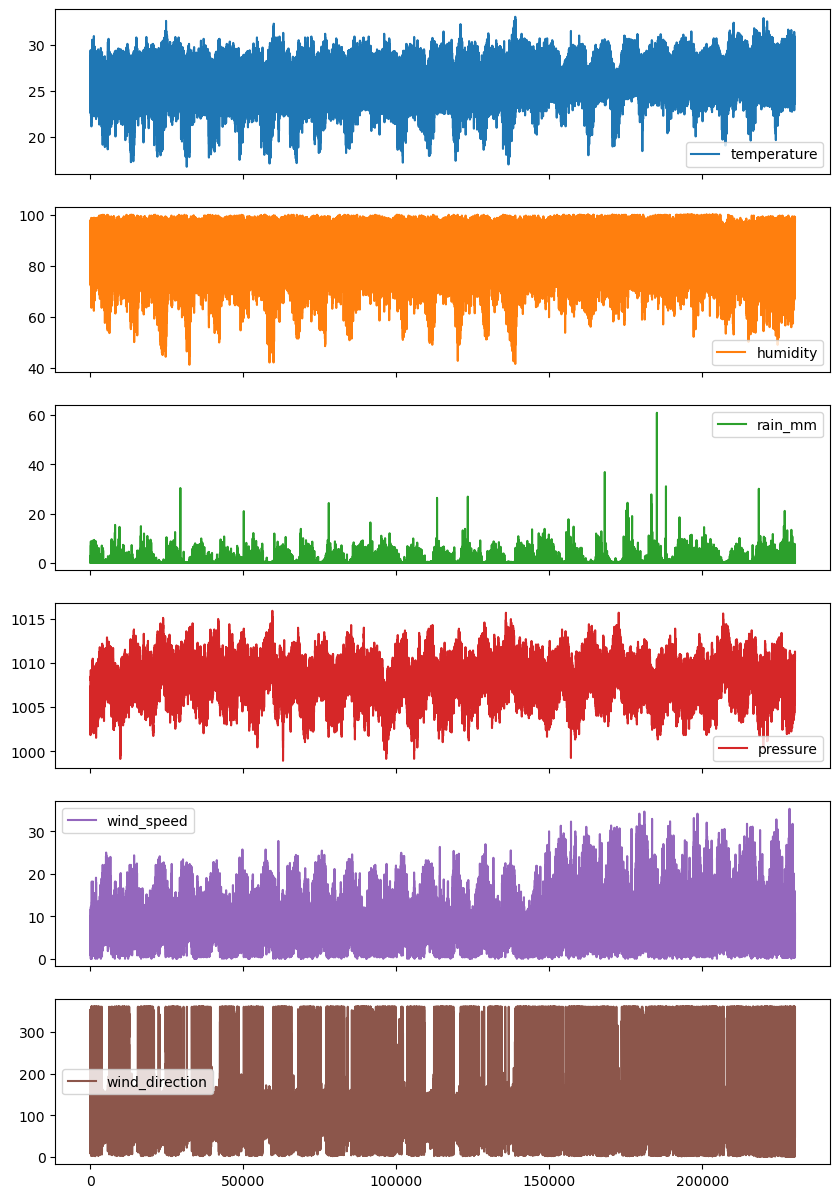

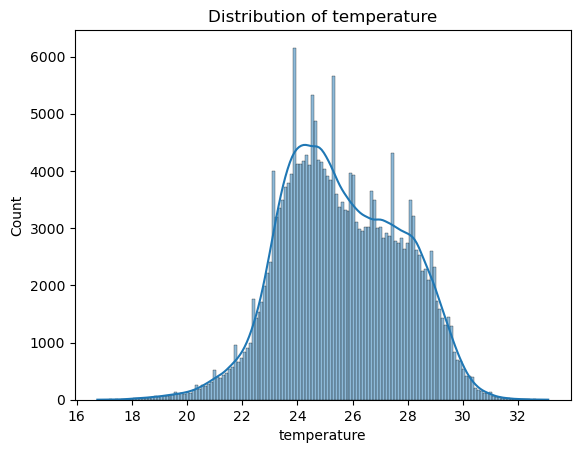

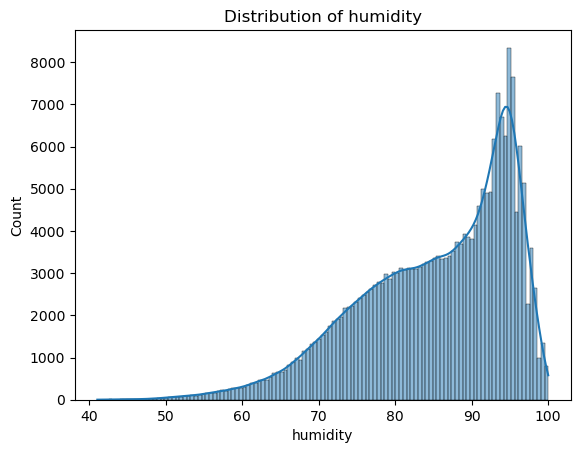

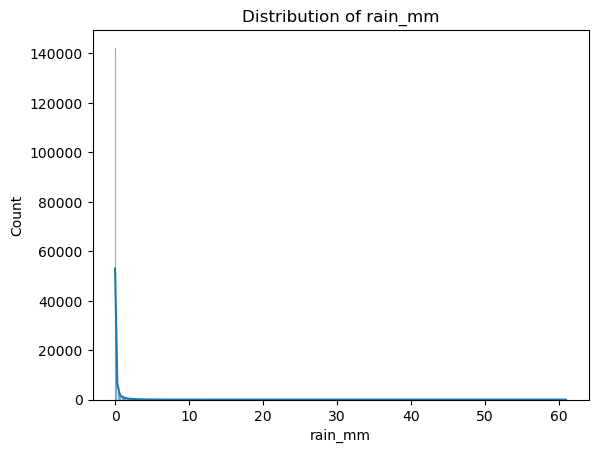

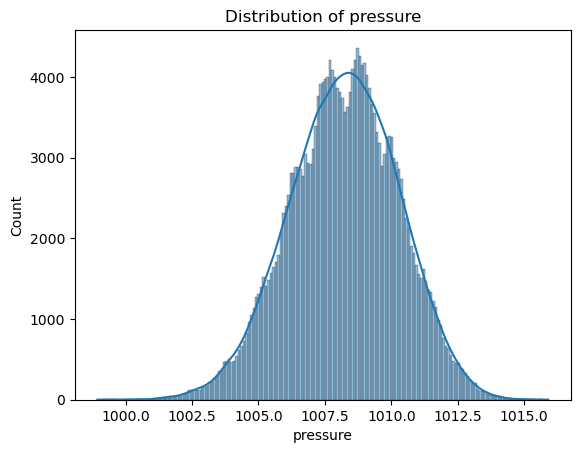

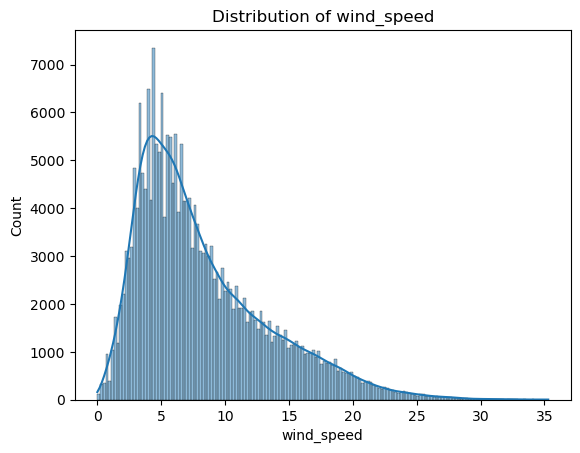

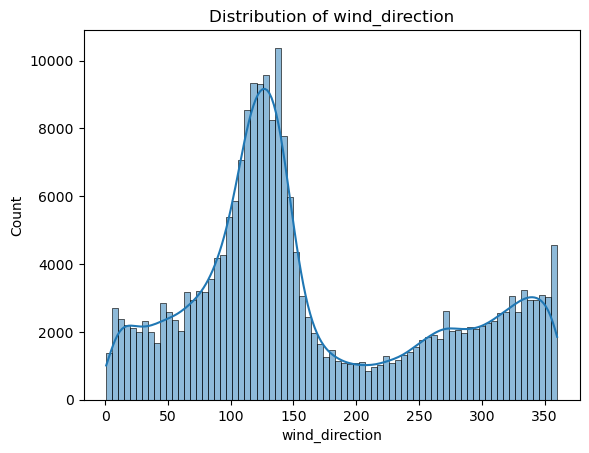

In [11]:
data_filtered.plot(
    y=[
    'temperature',  
    'humidity', 
    'rain_mm', 
    'pressure',
    'wind_speed',
    'wind_direction'
    ],
    subplots=True, figsize=(10, 15))
plt.show()

for column in [    
    'temperature',  
    'humidity', 
    'rain_mm', 
    'pressure',
    'wind_speed',
    'wind_direction']:
    sns.histplot(data_filtered[column], kde=True)
    plt.title(f'Distribution of {column}')
    plt.show()

# Pembersihan Data - Bagian Null Value

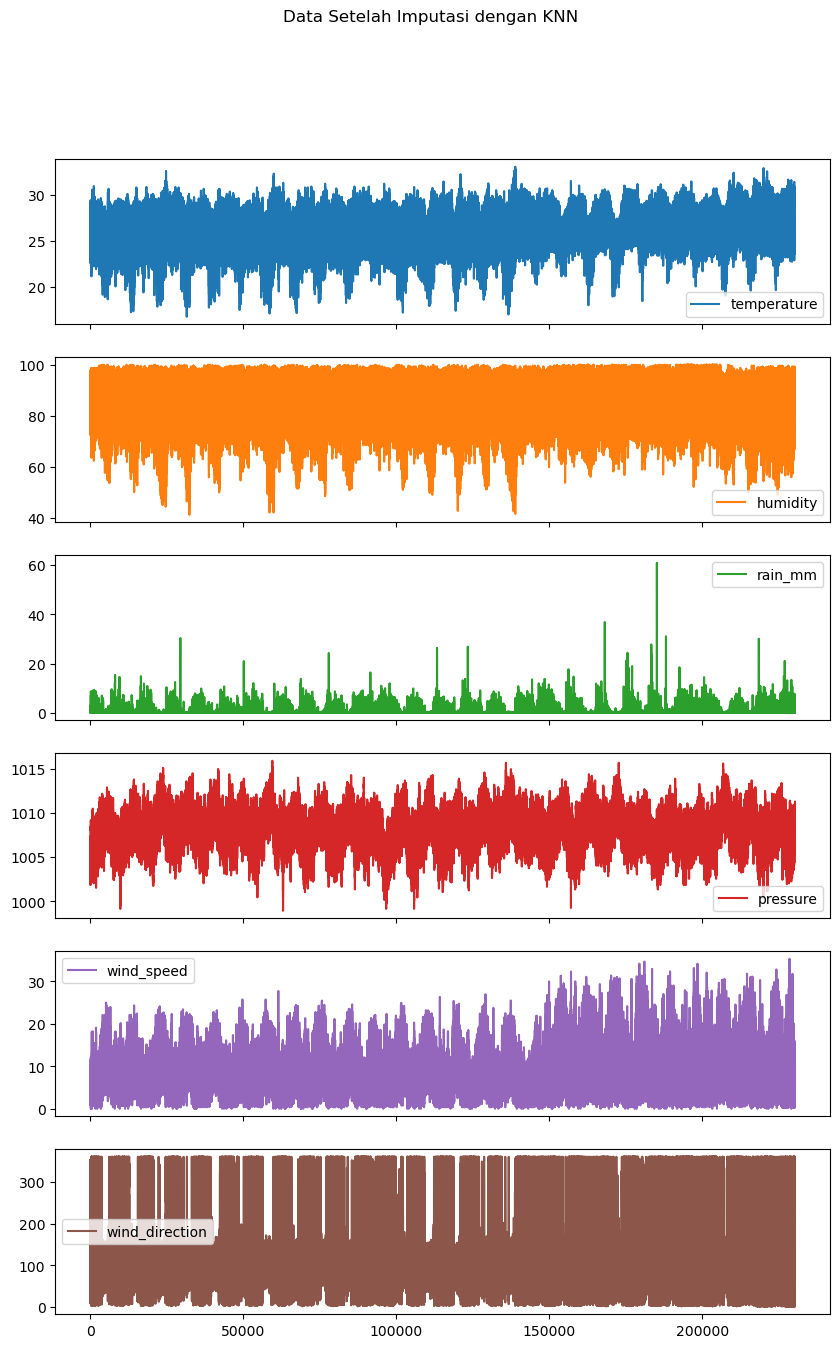

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer

# Daftar kolom yang akan digunakan
columns_to_clean = [
    'temperature',  
    'humidity', 
    'rain_mm', 
    'pressure',
    'wind_speed',
    'wind_direction'
]

# Inisialisasi KNN Imputer
knn_imputer = KNNImputer(n_neighbors=5, weights="uniform")  # Menggunakan 5 tetangga terdekat

# Mengganti NaN dengan KNN Imputer dan menyimpan hasil ke DataFrame baru
data3_cleaned = data_filtered.copy()
data3_cleaned[columns_to_clean] = knn_imputer.fit_transform(data_filtered[columns_to_clean])

# Visualisasi data setelah menggantikan NaN
data3_cleaned.plot(
    y=columns_to_clean,
    subplots=True,
    figsize=(10, 15),
    title='Data Setelah Imputasi dengan KNN'
)
plt.show()


In [13]:
data3_cleaned.isnull().sum()

temperature       0
humidity          0
rain_mm           0
pressure          0
wind_speed        0
wind_direction    0
dtype: int64

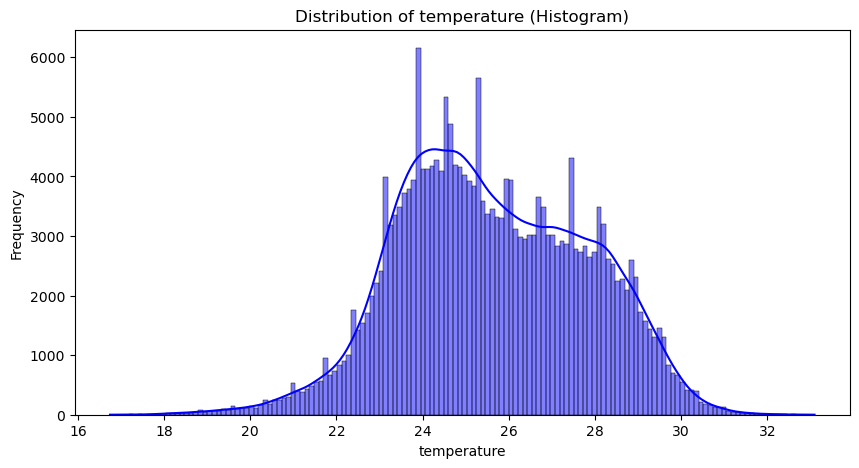

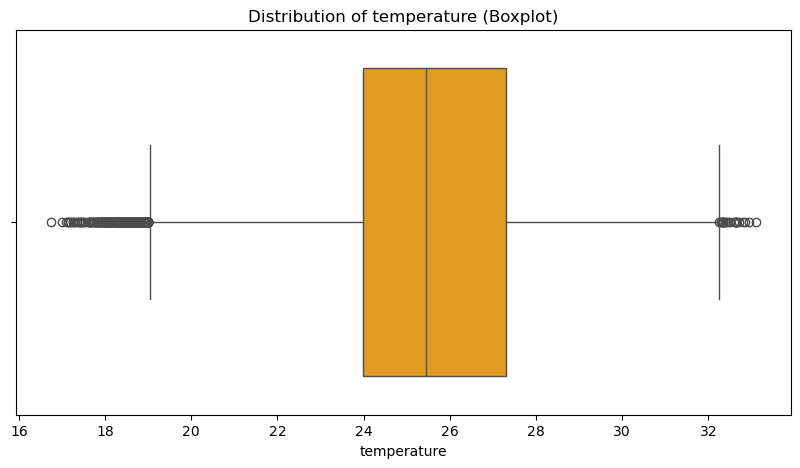

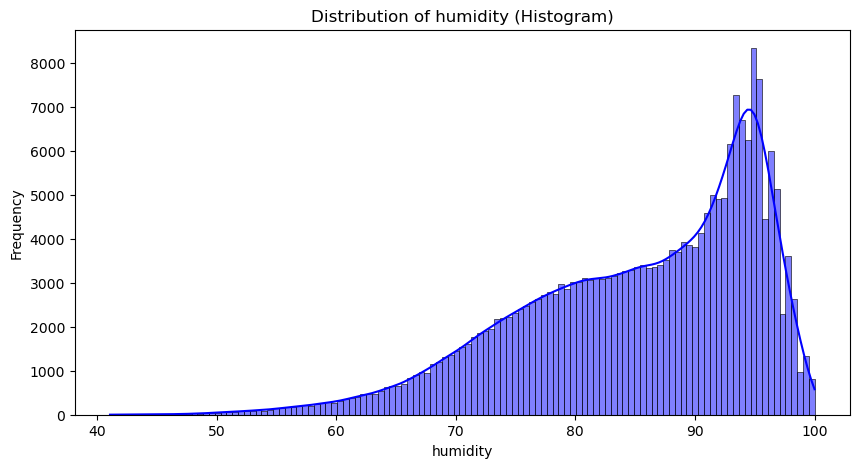

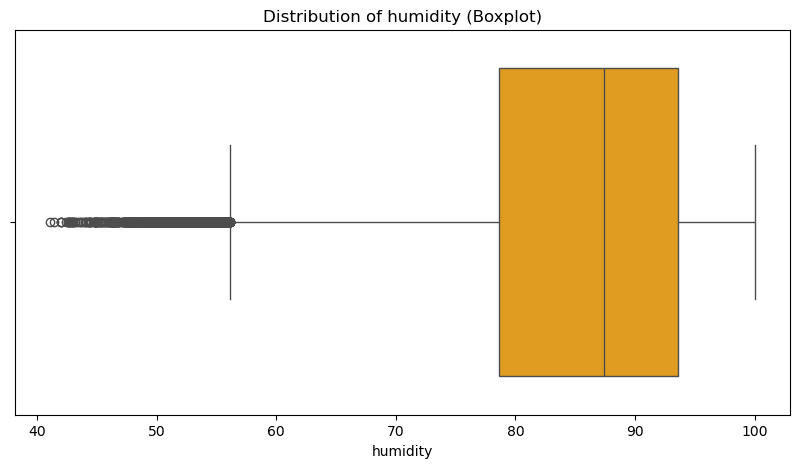

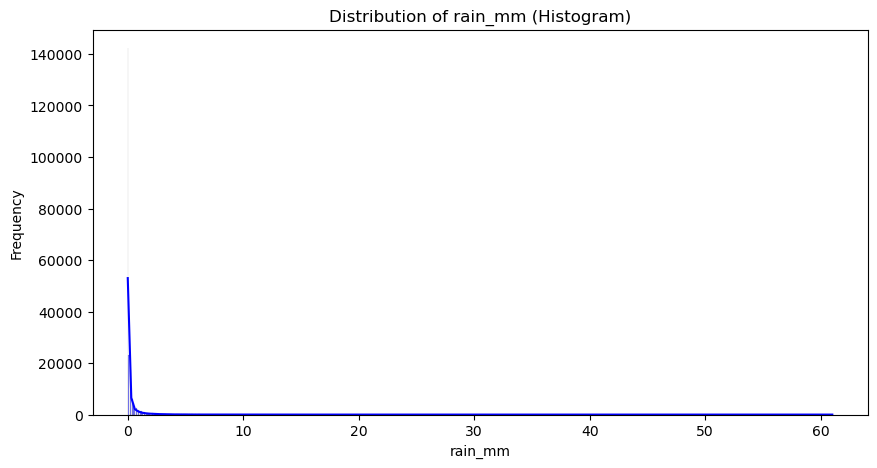

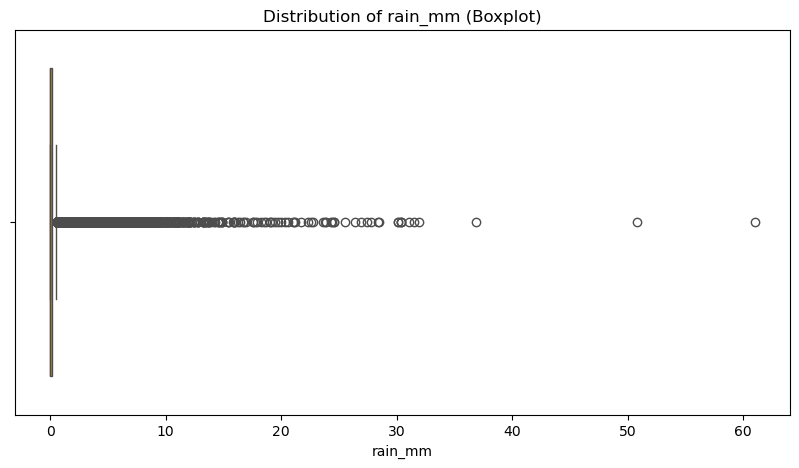

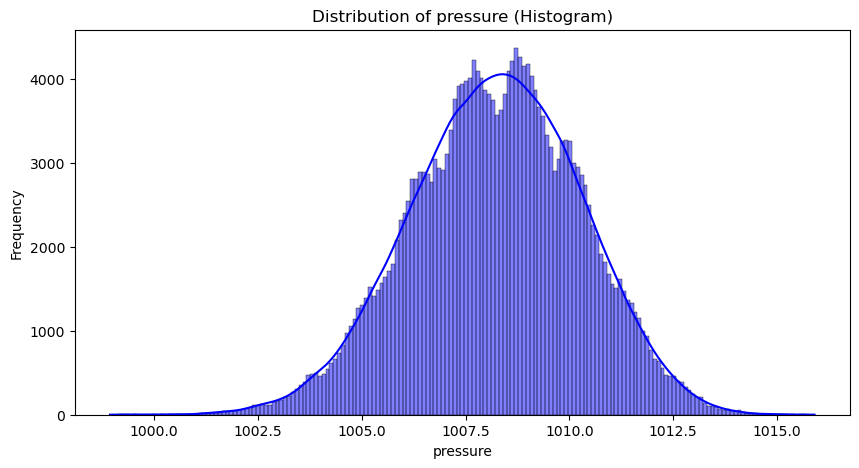

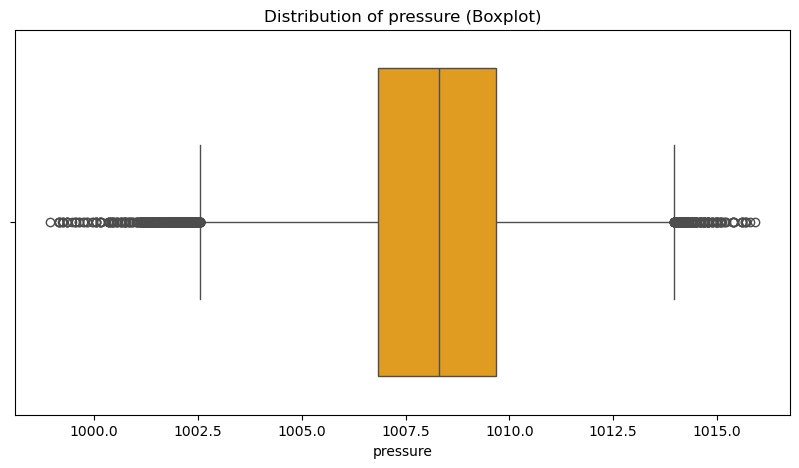

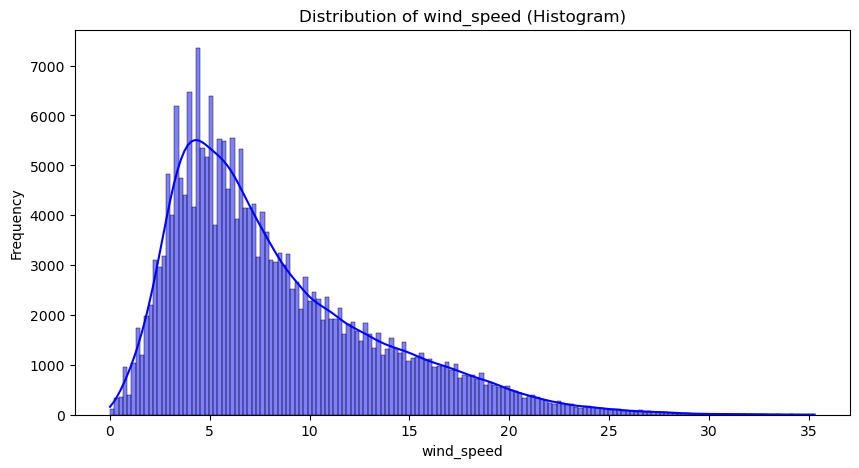

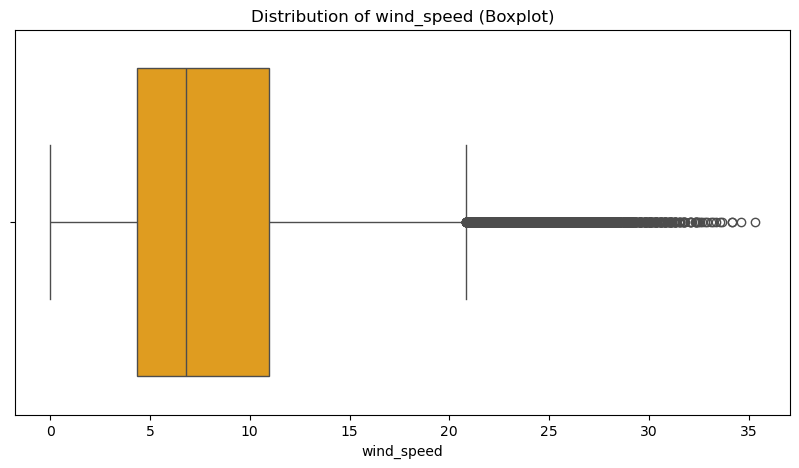

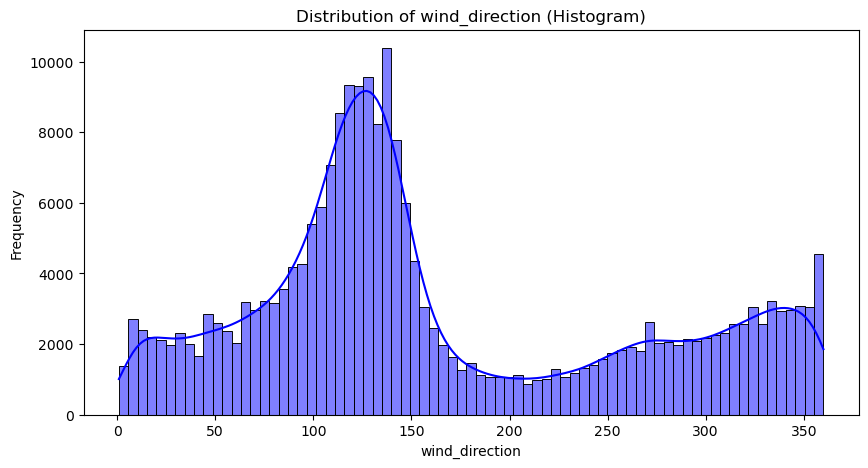

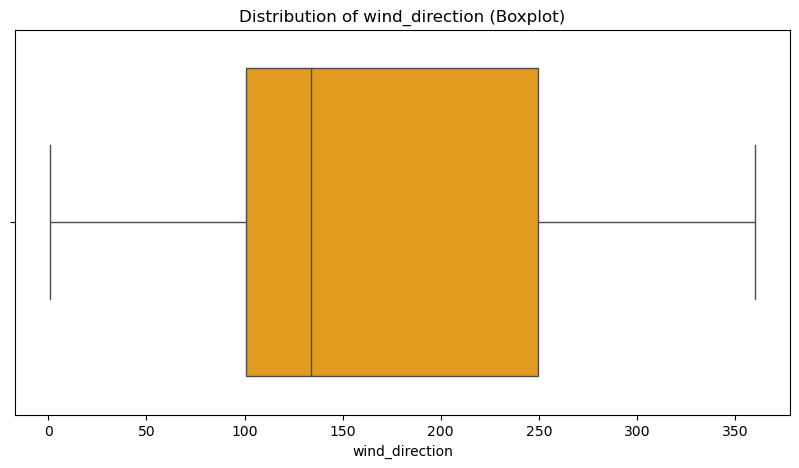

In [14]:
# Daftar kolom yang akan divisualisasikan
columns = [    
    'temperature',  
    'humidity', 
    'rain_mm', 
    'pressure',
    'wind_speed',
    'wind_direction'
    ]

# Loop untuk membuat histogram dan boxplot
for column in columns:
    # Histogram
    plt.figure(figsize=(10, 5))
    sns.histplot(data3_cleaned[column], kde=True, color='blue')
    plt.title(f'Distribution of {column} (Histogram)')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.show()
    
    # Boxplot
    plt.figure(figsize=(10, 5))
    sns.boxplot(x=data3_cleaned[column], color='orange')
    plt.title(f'Distribution of {column} (Boxplot)')
    plt.xlabel(column)
    plt.show()

# Pembersihan Data - Bagian Outliers 

In [15]:
import numpy as np
import pandas as pd

# Salin data asli
data_fix = data3_cleaned.copy()

# ==============================================================================
# STRATEGI 1: CLEANING MENGGUNAKAN IQR (Untuk Variabel Normal)
# ==============================================================================
# Cocok untuk: Suhu, Kelembaban, Tekanan, Kecepatan Angin (kadang)
cols_iqr = [
    'temperature',
    'humidity',
    'pressure',
    'wind_speed'
]

def clean_with_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    # Gunakan multiplier 3.0 (bukan 1.5) untuk data cuaca agar tidak terlalu agresif
    # Cuaca ekstrem itu nyata, kita tidak mau menghapus badai asli.
    lower_bound = Q1 - 3.0 * IQR 
    upper_bound = Q3 + 3.0 * IQR 

    # Cek outlier
    mask_outlier = (df[column] < lower_bound) | (df[column] > upper_bound)
    
    # Ganti dengan median (lebih aman daripada mean)
    if mask_outlier.sum() > 0:
        median_val = df[column].median()
        print(f"   -> {column}: Mengganti {mask_outlier.sum()} outlier dengan median {median_val:.2f}")
        df.loc[mask_outlier, column] = median_val

print("1️⃣ Membersihkan Variabel Fisika Biasa (IQR)...")
for col in cols_iqr:
    clean_with_iqr(data_fix, col)

# ==============================================================================
# STRATEGI 2: CLEANING MENGGUNAKAN BATAS FISIKA (Untuk Hujan & Arah Angin)
# ==============================================================================
# Hujan tidak boleh pakai IQR karena akan menghapus data banjir.
# Kita hanya hapus yang "Mustahil" secara fisika.

print("\n2️⃣ Membersihkan Variabel Hujan & Arah (Physical Limits)...")

# --- A. CLEANING HUJAN (rain_mm) ---
# Aturan: Tidak boleh negatif, dan tidak boleh > 500mm/jam (mustahil/sensor error)
col_rain = 'rain_mm'

# 1. Koreksi Negatif (Jadi 0)
mask_neg = data_fix[col_rain] < 0
if mask_neg.sum() > 0:
    print(f"   -> rain_mm: Mengubah {mask_neg.sum()} nilai negatif menjadi 0")
    data_fix.loc[mask_neg, col_rain] = 0

# 2. Koreksi Nilai Raksasa (Sensor Error)
# Hujan 300 mm/jam itu kiamat kecil. Biasanya sensor error. Kita cap di batas wajar.
LIMIT_HUJAN = 300 # mm/jam (Sesuaikan dengan lokasi, Indonesia jarang > 150mm/jam)
mask_giant = data_fix[col_rain] > LIMIT_HUJAN

if mask_giant.sum() > 0:
    print(f"   -> rain_mm: Memangkas {mask_giant.sum()} nilai > {LIMIT_HUJAN} mm (Sensor Error)")
    # Opsional: Ganti dengan NaN lalu interpolate, atau ganti dengan nilai limit
    data_fix.loc[mask_giant, col_rain] = LIMIT_HUJAN 

# --- B. CLEANING ARAH ANGIN (wind_direction) ---
# Arah angin itu lingkaran (0-360 derajat). IQR tidak berlaku.
col_dir = 'wind_direction'

# Pastikan 0 <= derajat <= 360
mask_dir_error = (data_fix[col_dir] < 0) | (data_fix[col_dir] > 360)
if mask_dir_error.sum() > 0:
    print(f"   -> wind_direction: Mengoreksi {mask_dir_error.sum()} data arah angin yang aneh")
    # Ganti dengan forward fill (nilai jam sebelumnya) karena arah angin biasanya kontinu
    data_fix.loc[mask_dir_error, col_dir] = np.nan
    data_fix[col_dir].fillna(method='ffill', inplace=True)

print("\n✅ Pembersihan Selesai!")
print(data_fix.describe()) # Cek statistik akhir

1️⃣ Membersihkan Variabel Fisika Biasa (IQR)...
   -> wind_speed: Mengganti 63 outlier dengan median 6.83

2️⃣ Membersihkan Variabel Hujan & Arah (Physical Limits)...

✅ Pembersihan Selesai!
         temperature       humidity        rain_mm       pressure  \
count  230280.000000  230280.000000  230280.000000  230280.000000   
mean       25.610519      85.301515       0.269314    1008.225939   
std         2.176430       9.843646       0.857751       2.051803   
min        16.745000      41.087536       0.000000     998.936700   
25%        23.995000      78.602217       0.000000    1006.827200   
50%        25.445000      87.412370       0.000000    1008.291750   
75%        27.295000      93.596437       0.200000    1009.681700   
max        33.094997     100.000000      61.000000    1015.904700   

          wind_speed  wind_direction  
count  230280.000000   230280.000000  
mean        8.191825      164.245878  
std         5.107345       97.734822  
min         0.000000        0.8

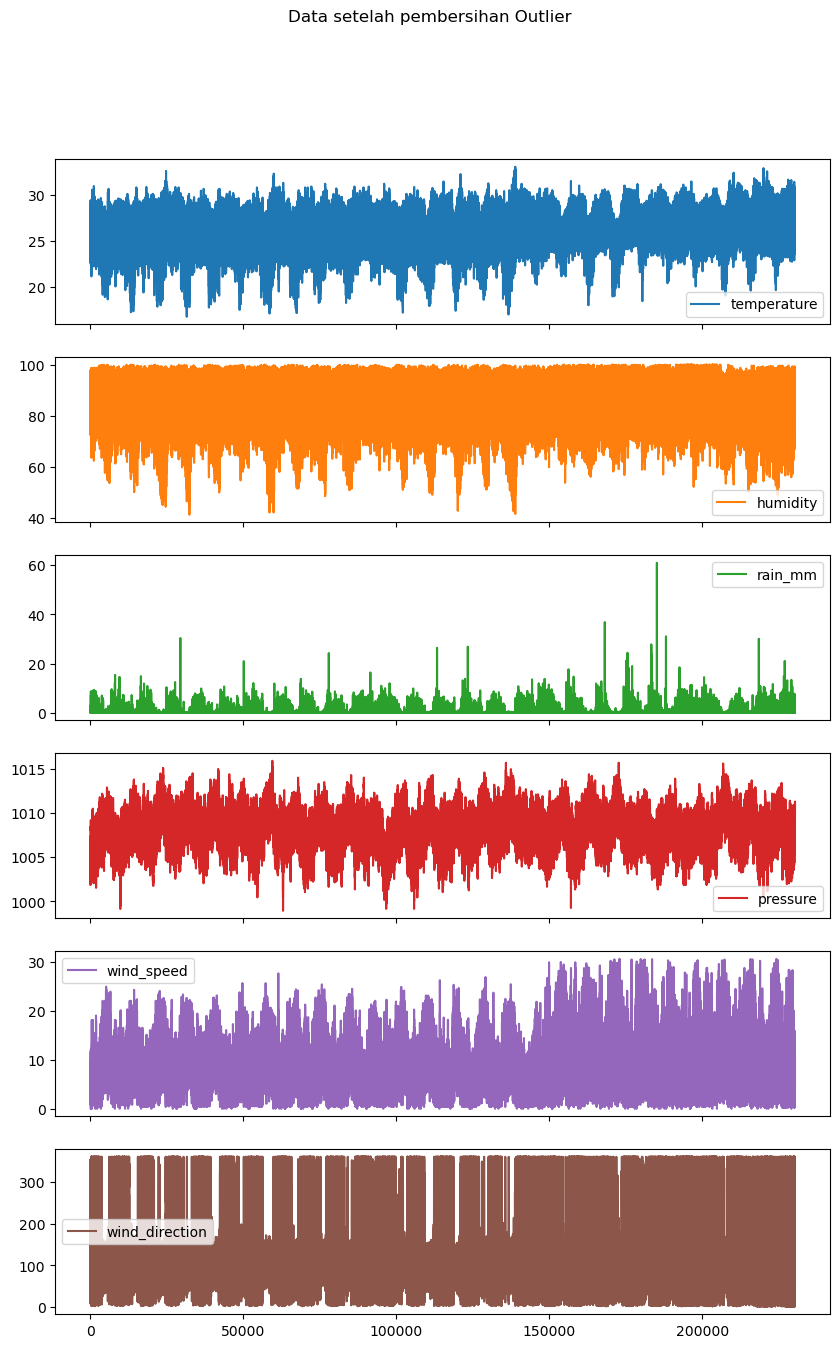

In [16]:
# Visualisasi data setelah menggantikan NaN
data_fix.plot(
    subplots=True,
    figsize=(10, 15),
    title='Data setelah pembersihan Outlier'
)
plt.show()

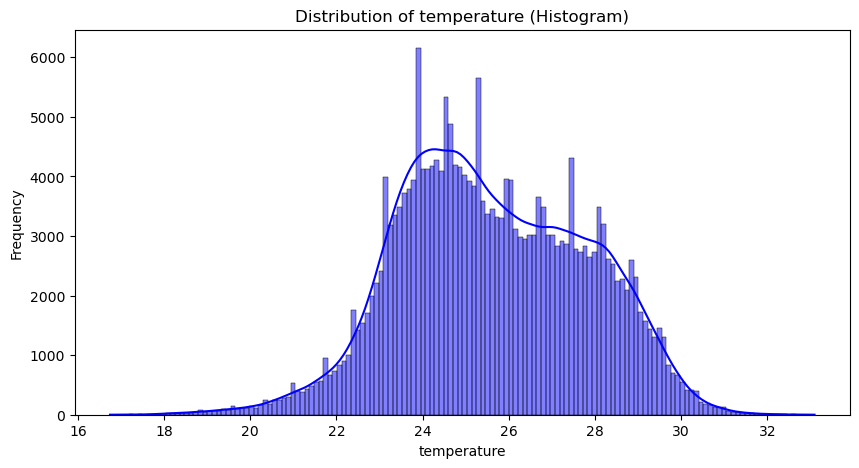

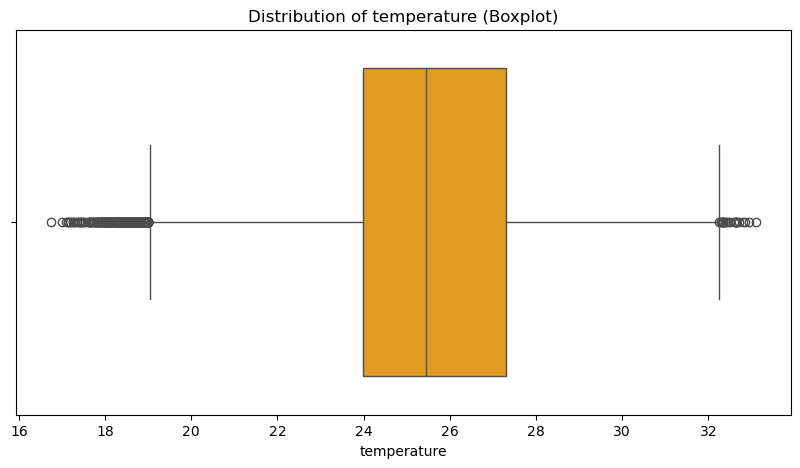

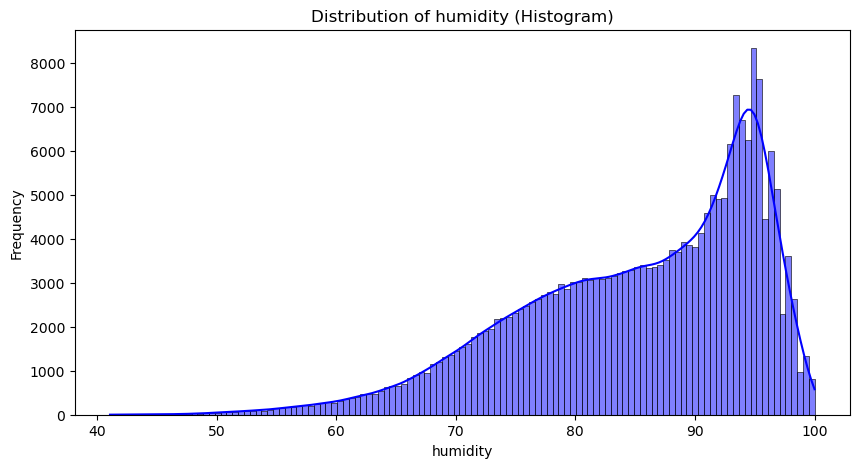

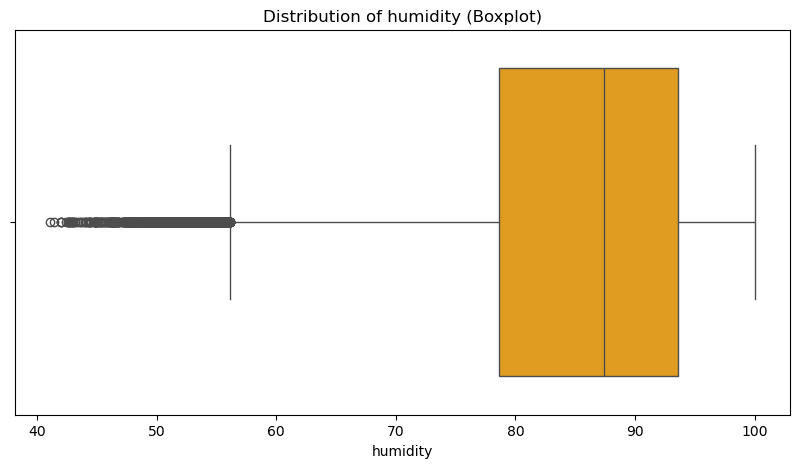

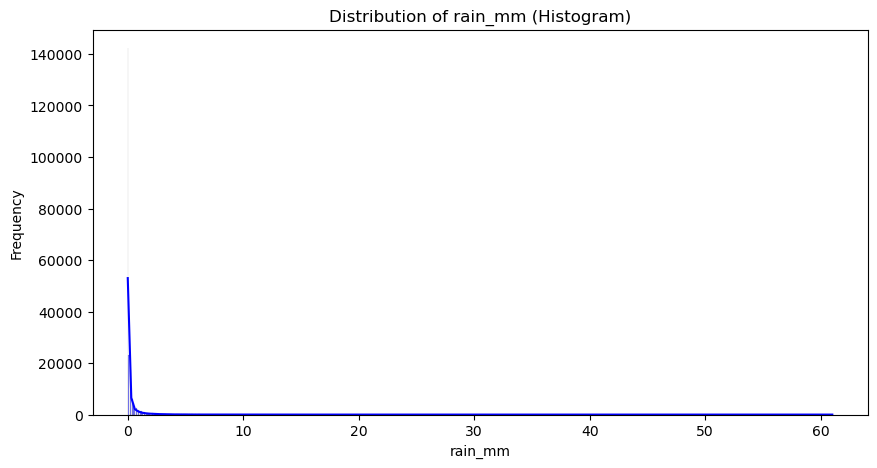

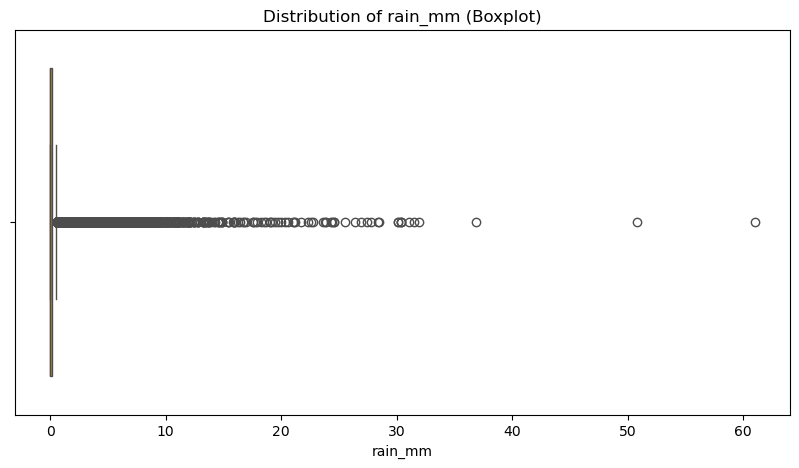

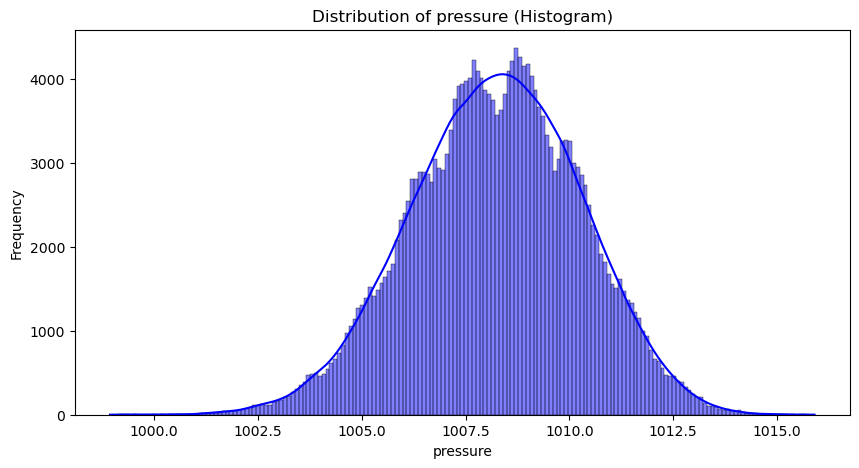

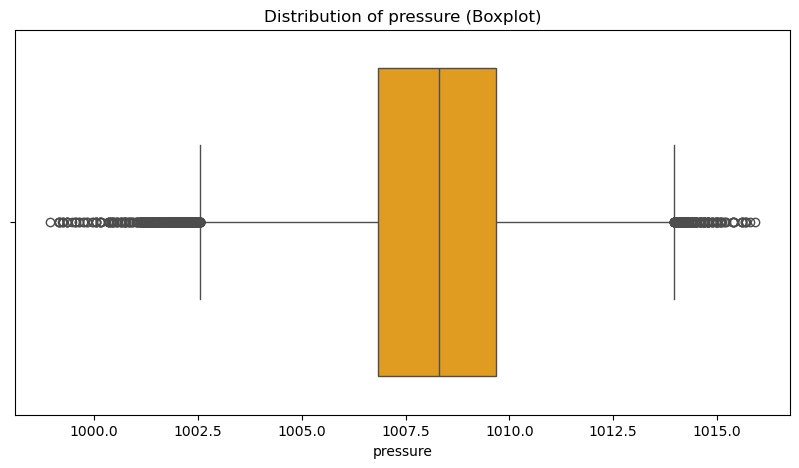

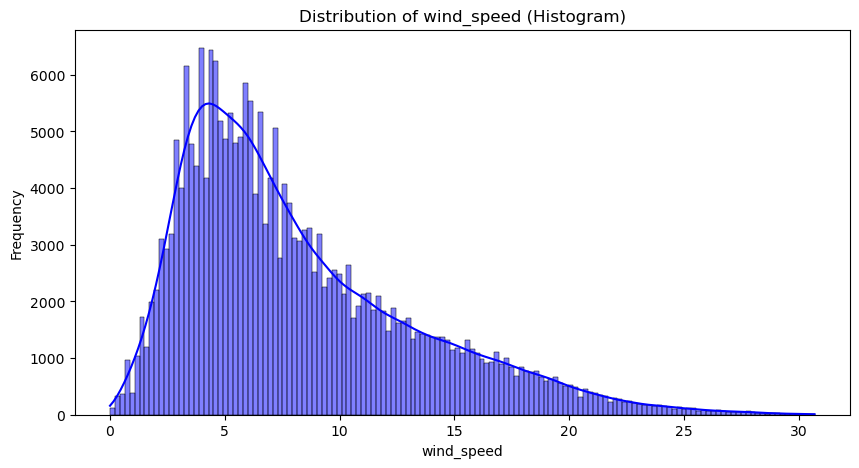

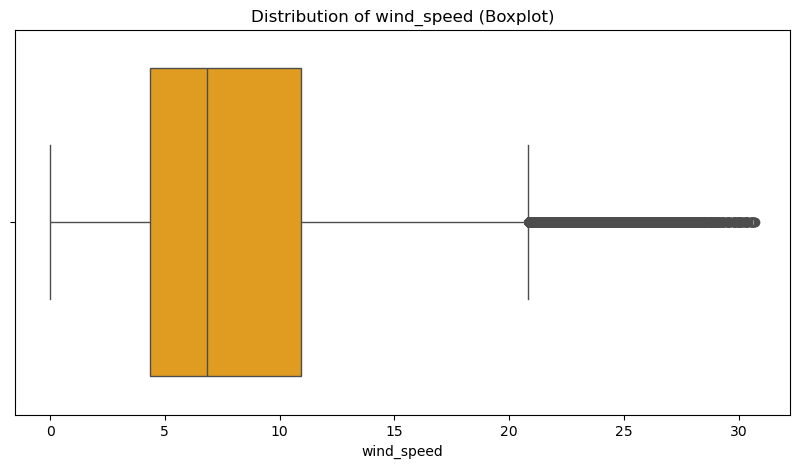

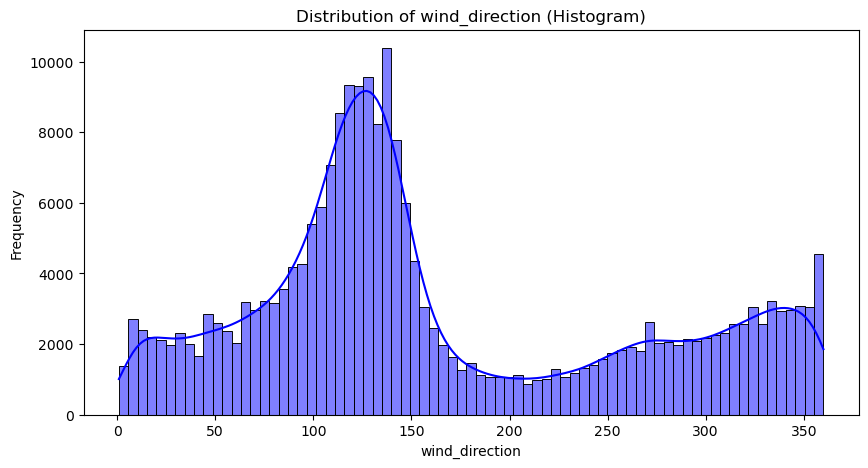

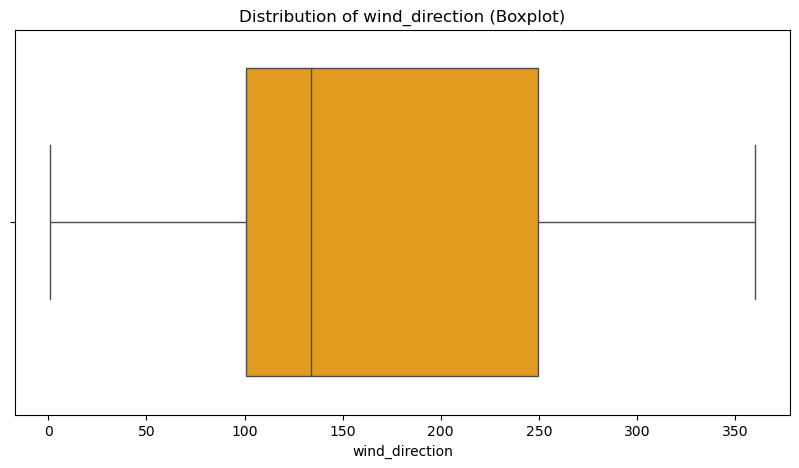

In [17]:
# Daftar kolom yang akan divisualisasikan
columns = [
    'temperature',  
    'humidity', 
    'rain_mm', 
    'pressure',
    'wind_speed',
    'wind_direction'
]

# Loop untuk membuat histogram dan boxplot
for column in columns:
    # Histogram
    plt.figure(figsize=(10, 5))
    sns.histplot(data_fix[column], kde=True, color='blue')
    plt.title(f'Distribution of {column} (Histogram)')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.show()
    
    # Boxplot
    plt.figure(figsize=(10, 5))
    sns.boxplot(x=data_fix[column], color='orange')
    plt.title(f'Distribution of {column} (Boxplot)')
    plt.xlabel(column)
    plt.show()

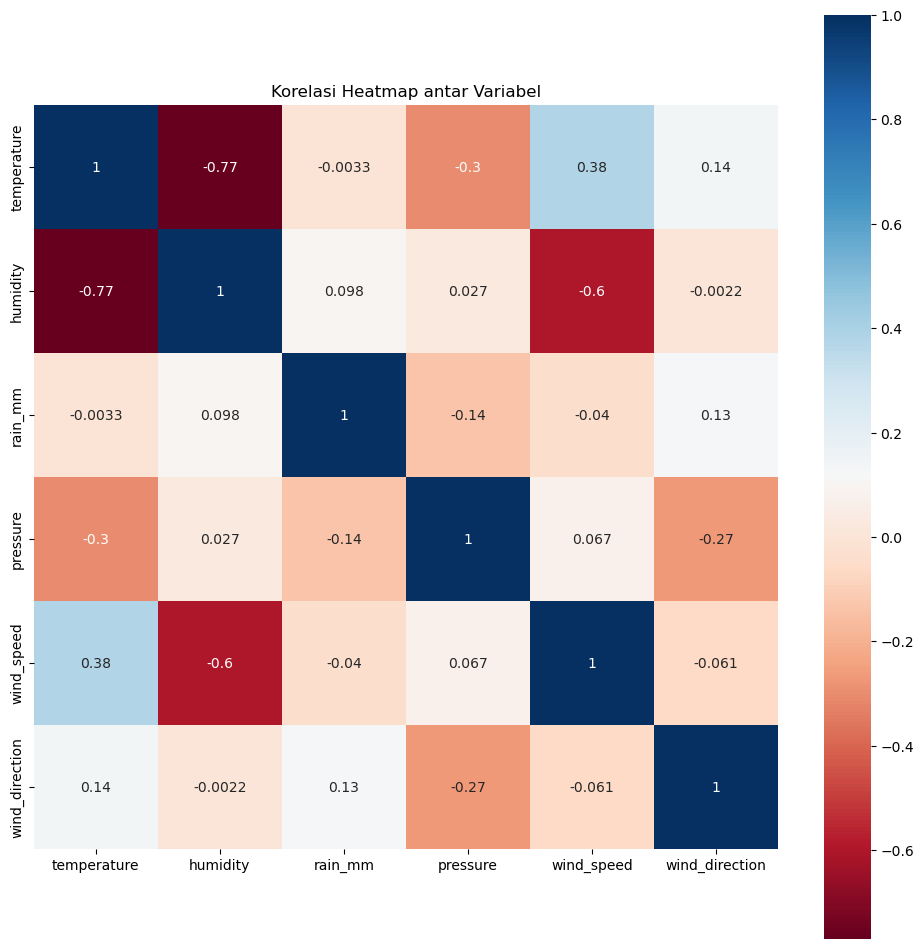

In [18]:
# Memilih hanya kolom yang diinginkan
selected_columns = [
    'temperature',  
    'humidity', 
    'rain_mm', 
    'pressure',
    'wind_speed',
    'wind_direction'
]

# Menghitung matriks korelasi hanya untuk kolom yang dipilih
corrmat = data_fix[selected_columns].corr()

# Menentukan palet warna untuk heatmap
cmap = sns.color_palette("RdBu", as_cmap=True)

# Membuat heatmap dengan ukuran yang sesuai
plt.figure(figsize=(12,12))
sns.heatmap(corrmat, cmap=cmap, annot=True, square=True)
plt.title('Korelasi Heatmap antar Variabel')
plt.show()

# Data Preproses - Membuat Target (Y)

In [19]:
# Rename the column 'precipprob' to 'precipToday'
data_fix.rename(columns={'precipprob': 'precipToday'}, inplace=True)

In [20]:
# Menambahkan kolom klasifikasi precip
def classify_precip(value):
    if 0 <= value <=0.1:
        return 'No Rain'
    elif 0.1 <= value <= 19.9:
        return 'Light'
    elif 20.0 <= value <= 49.9:
        return 'Medium'
    elif 50.0 <= value <= 99.9:
        return 'Heavy'
    elif value >= 100.0:
        return 'Extrem'
    else:
        return 'Unknown'  # Untuk nilai yang tidak masuk dalam range

# Terapkan klasifikasi ke kolom precip
data_fix['precip_class_Today'] = data_fix['rain_mm'].apply(classify_precip)

### Penggeseran Kolom biner hujan

<Axes: xlabel='precip_class_Today', ylabel='count'>

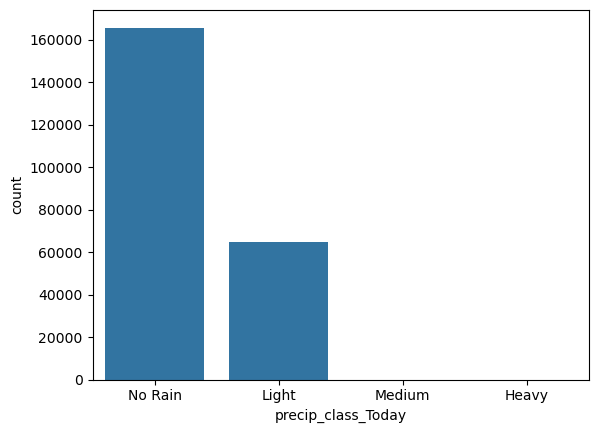

In [21]:
sns.countplot(x=data_fix["precip_class_Today"])

In [ ]:
data_fix

,temperature,humidity,rain_mm,pressure,wind_speed,wind_direction,precip_class_Today
0,23.904501,97.033630,0.0,1002.40784,3.240000,360.00000,No Rain
1,23.904501,97.033630,0.0,1001.60956,3.960000,360.00000,No Rain
2,24.054500,95.584400,0.0,1001.41080,4.802999,347.00537,No Rain
3,23.404501,96.729190,0.0,1001.30646,4.735060,351.25390,No Rain
4,23.654501,95.861200,0.0,1001.40810,5.411986,356.18600,No Rain
...,...,...,...,...,...,...,...
525955,24.945000,92.503975,0.1,1006.00750,3.877318,338.19852,No Rain
525956,24.695000,93.612620,0.0,1006.70410,5.241679,344.05453,No Rain
525957,24.495000,93.603355,0.0,1007.20170,5.506941,348.69010,No Rain
525958,24.295000,93.594070,0.0,1007.10034,5.771239,356.42374,No Rain


In [ ]:
data_fix.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525960 entries, 0 to 525959
Data columns (total 7 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   temperature         525960 non-null  float64
 1   humidity            525960 non-null  float64
 2   rain_mm             525960 non-null  float64
 3   pressure            525960 non-null  float64
 4   wind_speed          525960 non-null  float64
 5   wind_direction      525960 non-null  float64
 6   precip_class_Today  525960 non-null  object 
dtypes: float64(6), object(1)
memory usage: 28.1+ MB


In [ ]:
data_fix.describe()

,temperature,humidity,rain_mm,pressure,wind_speed,wind_direction
count,525960.000000,525960.000000,525960.000000,525960.000000,525960.000000,525960.000000
mean,24.919208,85.978013,0.271534,1008.226834,7.617961,160.584154
std,2.217868,10.208835,0.796068,1.970508,4.463502,94.378411
min,15.645000,35.354060,0.000000,998.936700,0.000000,1.909111
25%,23.295000,79.610200,0.000000,1006.898250,4.334974,100.304790
50%,24.545000,88.703070,0.000000,1008.287050,6.569383,132.184370
75%,26.695000,94.372345,0.200000,1009.595460,9.957109,229.763720
max,33.495000,100.000000,30.400000,1016.285340,26.785547,360.000000


In [ ]:
data_fix.isna().sum()

temperature           0
humidity              0
rain_mm               0
pressure              0
wind_speed            0
wind_direction        0
precip_class_Today    0
dtype: int64

In [ ]:
# Library Dasar
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Model dan Algoritma
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# Data Processing dan Evaluasi
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay

# Membagi variabel independen dan target
X = data_fix[[
    'temp', 
    'tempmax',
    'tempmin',
    'humidity',
    'precip',
    'sealevelpressure',
    'windspeed'
]]  # Variabel independen
y = data_fix['precip_class_Tomorrow']  # Target (multiclass classification)

# Membagi dataset menjadi data latih dan data uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=50)

# Normalisasi fitur numerik
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Binarisasi target untuk ROC AUC multikelas
classes = y.unique()  # Daftar kelas
y_train_bin = label_binarize(y_train, classes=classes)
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_train_bin.shape[1]

# Daftar model klasifikasi
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=100),
    'Random Forest': RandomForestClassifier(random_state=100),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Support Vector Machine': SVC(probability=True, random_state=100),
    'Neural Networks': MLPClassifier(random_state=100, max_iter=1000)
}

# Evaluasi model dan penyimpanan hasil
results = []

# Plot ROC Curve untuk setiap model secara terpisah
for idx, (name, model) in enumerate(models.items()):
    # Melatih model
    model.fit(X_train_scaled, y_train)
    
    # Prediksi
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)  # Probabilitas untuk semua kelas

    # Evaluasi performa dasar
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision (macro avg)': report['macro avg']['precision'],
        'Recall (macro avg)': report['macro avg']['recall'],
        'F1-Score (macro avg)': report['macro avg']['f1-score']
    })
    
    # Menampilkan Confusion Matrix
    cm = confusion_matrix(y_test, y_pred, labels=classes)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f'Confusion Matrix for {name}')
    plt.show()
    
    # Plot ROC Curve untuk tiap kelas dalam model
    plt.figure(figsize=(8, 6))
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(
            fpr, 
            tpr, 
            linestyle='-', 
            label=f'Class {classes[i]} (AUC = {roc_auc:.2f})')
    
    # Menambahkan garis diagonal sebagai referensi untuk prediksi acak
    plt.plot([0, 1], [0, 1], color='black', linestyle='--', label='Random Prediction')
    
    # Pengaturan grafik ROC untuk model
    plt.title(f'ROC Curve for {name}')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right', fontsize='small')
    plt.grid(True)
    plt.show()

# Menampilkan tabel hasil evaluasi
results_df = pd.DataFrame(results)
print("Hasil Evaluasi Model:")
print(results_df)


KeyError: "['temp', 'tempmax', 'tempmin', 'precip', 'sealevelpressure', 'windspeed'] not in index"

In [ ]:
data_fix.head(10)

,datetime,tempmax,tempmin,temp,humidity,precip,sealevelpressure,windspeed,winddir,precipToday,precip_class_Today,precipTomorrow,precip_class_Tomorrow
0,1978-02-16,32.1,25.1,28.1,83.5,0.0,1011.70000,18.4,183.2,0.0,No Rain,0.0,No Rain
1,1978-02-17,31.1,25.1,27.9,84.4,0.0,1012.50000,18.4,120.5,0.0,No Rain,0.0,No Rain
2,1978-02-18,32.1,26.1,29.0,82.7,0.0,1013.00000,9.4,99.7,0.0,No Rain,0.0,No Rain
3,1978-02-19,33.1,25.1,28.5,83.2,0.0,1013.30000,14.8,234.8,0.0,No Rain,0.0,No Rain
4,1978-02-20,31.1,24.1,27.1,85.2,0.0,1013.60000,5.4,148.1,0.0,No Rain,0.0,No Rain
5,1978-02-21,30.1,24.1,26.1,92.2,0.0,1013.70000,5.4,263.4,0.0,No Rain,0.0,No Rain
6,1978-02-22,31.1,24.1,27.4,89.7,0.0,1012.70000,18.4,243.4,0.0,No Rain,100.0,Light
7,1978-02-23,29.1,24.1,27.0,87.8,9.0,1013.30000,11.2,294.6,100.0,Light,0.0,No Rain
8,1978-02-24,32.1,25.1,27.0,87.7,0.0,1014.10000,11.2,232.5,0.0,No Rain,0.0,No Rain
9,1978-02-25,33.1,24.1,27.8,83.0,0.0,1011.17015,13.0,271.7,0.0,No Rain,0.0,No Rain


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Konversi kolom 'datetime' menjadi format datetime jika belum dilakukan
data_fix['datetime'] = pd.to_datetime(data_fix['datetime'])

# Set 'datetime' sebagai index untuk analisis waktu
data_fix.set_index('datetime', inplace=True)


C:\Users\acer\AppData\Local\Temp\ipykernel_22868\2159918027.py:11: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_rainfall = data_fix['precip'].resample('M').sum()
C:\Users\acer\AppData\Local\Temp\ipykernel_22868\2159918027.py:14: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  yearly_rainfall = data_fix['precip'].resample('Y').sum()
C:\Users\acer\AppData\Local\Temp\ipykernel_22868\2159918027.py:17: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  seasonal_rainfall = data_fix['precip'].resample('Q').sum()


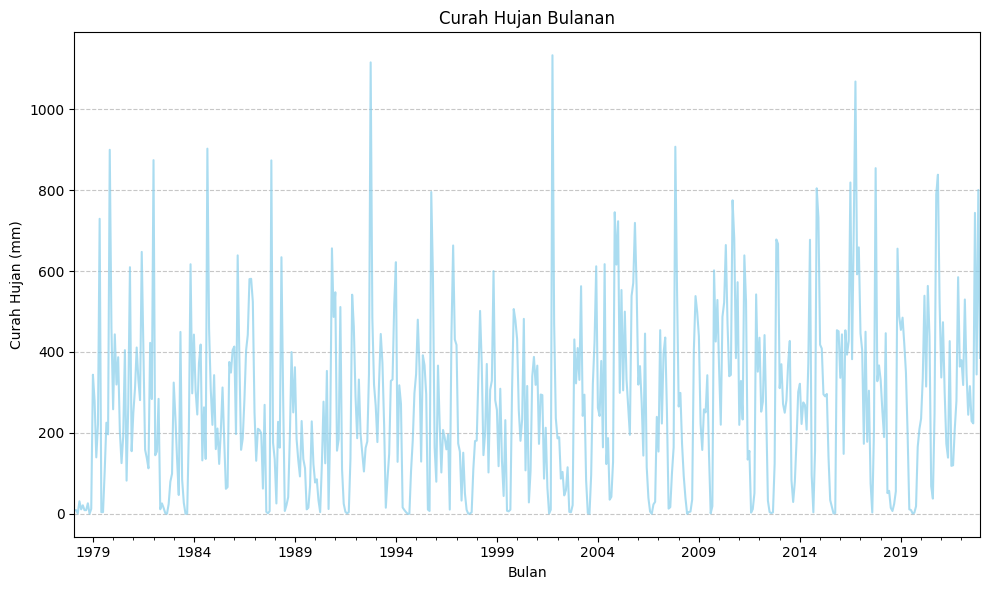

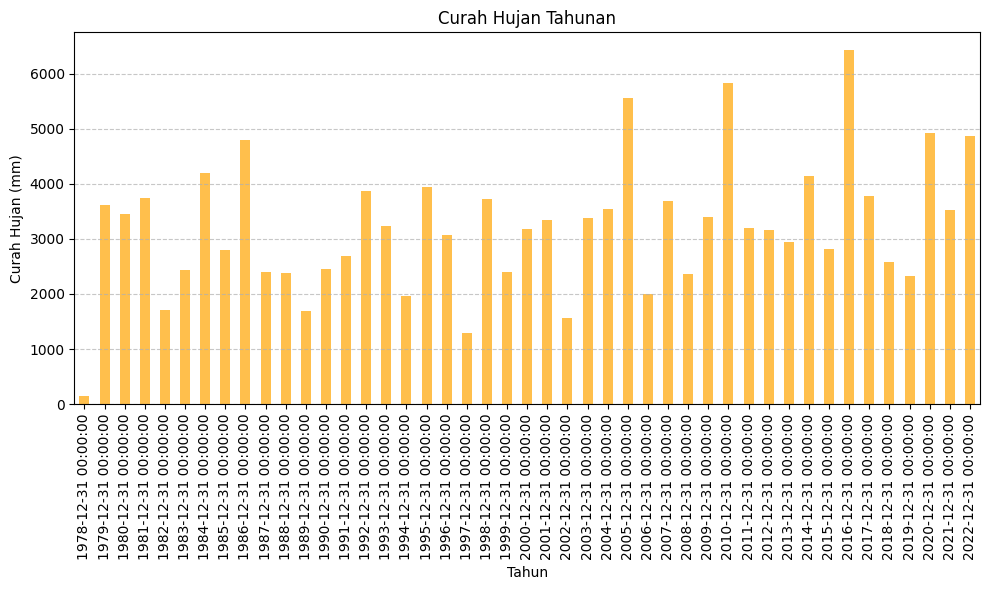

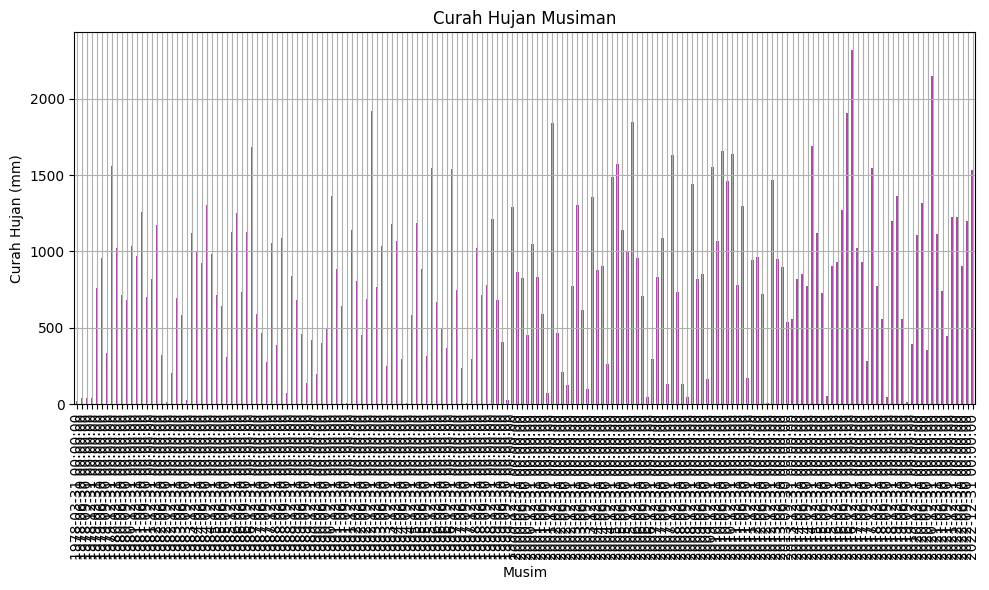

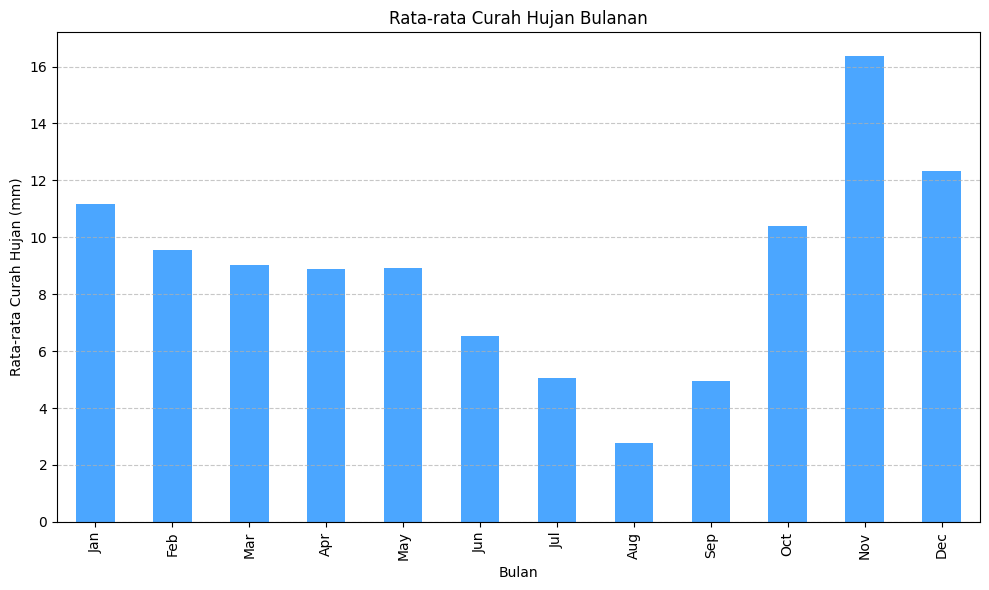

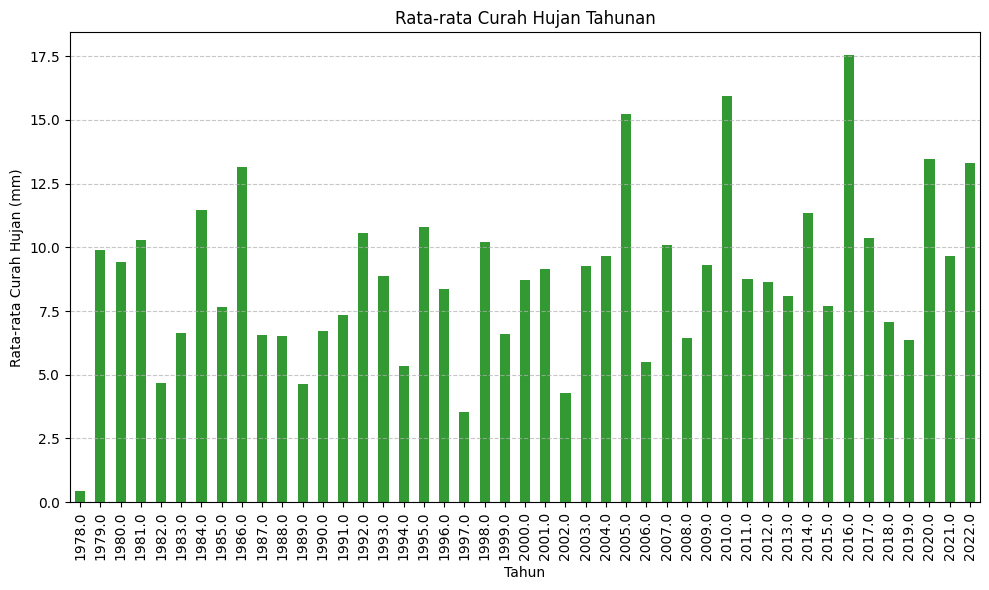

In [ ]:
# Menambahkan kolom satuan waktu dari variabel datetime
data_fix['year'] = data_fix.index.year
data_fix['month'] = data_fix.index.month
data_fix['day'] = data_fix.index.day

# Agregasi curah hujan berdasarkan satuan waktu tertentu
# Curah hujan harian
daily_rainfall = data_fix['precip'].resample('D').sum()

# Curah hujan bulanan
monthly_rainfall = data_fix['precip'].resample('M').sum()

# Curah hujan tahunan
yearly_rainfall = data_fix['precip'].resample('Y').sum()

# Curah hujan musiman
seasonal_rainfall = data_fix['precip'].resample('Q').sum()

# Menghitung rata-rata curah hujan per bulan (menggabungkan semua tahun)
average_monthly_rainfall = data_fix.groupby('month')['precip'].mean()

# Menghitung rata-rata curah hujan per tahun
average_yearly_rainfall = data_fix.groupby('year')['precip'].mean()

# Visualisasi Curah Hujan Bulanan
plt.figure(figsize=(10, 6))
monthly_rainfall.plot(kind='line', color='skyblue', alpha=0.7)
plt.title("Curah Hujan Bulanan")
plt.xlabel("Bulan")
plt.ylabel("Curah Hujan (mm)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Visualisasi Curah Hujan Tahunan
plt.figure(figsize=(10, 6))
yearly_rainfall.plot(kind='bar', color='orange', alpha=0.7)
plt.title("Curah Hujan Tahunan")
plt.xlabel("Tahun")
plt.ylabel("Curah Hujan (mm)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Visualisasi Curah Hujan Musiman
plt.figure(figsize=(10, 6))
seasonal_rainfall.plot(kind='bar', color='purple', alpha=0.7)
plt.title("Curah Hujan Musiman")
plt.xlabel("Musim")
plt.ylabel("Curah Hujan (mm)")
plt.grid()
plt.tight_layout()
plt.show()

# Visualisasi rata-rata curah hujan per bulan
plt.figure(figsize=(10, 6))
average_monthly_rainfall.plot(kind='bar', color='dodgerblue', alpha=0.8)
plt.title("Rata-rata Curah Hujan Bulanan")
plt.xlabel("Bulan")
plt.ylabel("Rata-rata Curah Hujan (mm)")
plt.xticks(ticks=range(12), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Visualisasi rata-rata curah hujan per tahun
plt.figure(figsize=(10, 6))
average_yearly_rainfall.plot(kind='bar', color='green', alpha=0.8)
plt.title("Rata-rata Curah Hujan Tahunan")
plt.xlabel("Tahun")
plt.ylabel("Rata-rata Curah Hujan (mm)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=200afad5-8991-4e20-8a55-8751c7aff3b5' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>